# Neural Network Workshop: Classifying MNIST Digits, Then Peeking Inside the Network with PCA

**Time:** ~90 minutes

### The Big Picture
Today you'll build and train your own neural network — using PyTorch, one of the most widely used deep learning libraries — to recognize handwritten digits (0-9) from the famous MNIST dataset. Along the way you'll pick up one of the most important debugging habits in machine learning: proving your training loop works on a single example before you ever trust it on thousands. Once your network can classify digits well, we'll do something sneakier: peek at the layer *just before* the network makes its final decision, and use a technique called **PCA** to show that the network has learned to group similar-looking digits together — even though nobody ever told it to cluster anything. We'll do it in 5 steps:

1. **Build the network** — define the layers of a neural network in PyTorch
2. **Debug on one example** — before trusting your training loop on thousands of images, prove it works on a single one
3. **Train on the full dataset** — scale up to mini-batches, multiple epochs, and a held-out test set
4. **Meet PCA** — a short detour with toy data to understand what "reducing dimensions" actually means
5. **Discover the clusters** — apply PCA to your network's internal representation of each digit, and watch the digits sort themselves into groups

Each question builds on the one before it, so try not to skip ahead. Raise your hand any time you get stuck!

### Before we start: get the libraries and data
Run the two cells below. The first loads the libraries you'll need — `torch` for building and training the neural network, plus the `sklearn` and plotting tools you already know from the iris workshop. The second downloads MNIST (70,000 handwritten digit images, 28x28 pixels each) via scikit-learn and gets it ready for PyTorch. Both cells are given to you as-is — no TODOs here, just run them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

torch.manual_seed(42)
print("Ready to go!")

Ready to go!


Train: torch.Size([8000, 784]) Test: torch.Size([2000, 784])


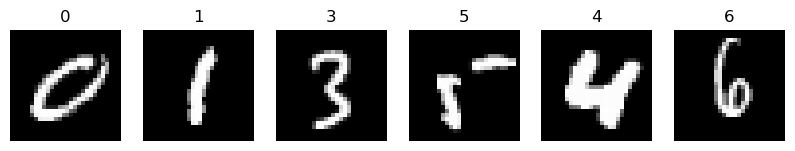

In [2]:
print("Downloading MNIST (this can take a minute the first time)...")
mnist_X, mnist_y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
mnist_y = mnist_y.astype(int)

# We use a subset of the 70,000 images so training stays fast on a laptop CPU.
X_train, X_test, y_train, y_test = train_test_split(
    mnist_X, mnist_y, train_size=8000, test_size=2000, stratify=mnist_y, random_state=42
)

# Pixel values are 0-255; scale to 0-1, which neural networks train on much more easily.
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print("Train:", X_train_t.shape, "Test:", X_test_t.shape)

# Peek at a few digits
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(str(y_train[i]))
    ax.axis("off")
plt.show()

---
## Question 1: Build the Network

Every image in MNIST is a 28x28 grid of pixel brightness values — we've already flattened that into a single list of 784 numbers per image. Your network will pass those 784 numbers through a few layers, each one recombining the information, until it produces 10 numbers at the very end: one score per digit (0-9). The digit with the highest score is the network's prediction.

We care about one layer in particular: the **second-to-last layer**, right before the final 10-number output. This layer is often called an *embedding* — the network's own compressed description of the image, in whatever terms it finds useful for telling digits apart. In Question 5 you'll use PCA to peek at that description and see something remarkable.

**Your tasks:**
1. Complete the `MNISTNet` class below. It should have three layers:
   - `fc1`: 784 inputs → 128 outputs
   - `fc2`: 128 inputs → 32 outputs (this is the *embedding* layer)
   - `fc3`: 32 inputs → 10 outputs (one score per digit)
2. In `forward`, pass the input through `fc1`, apply a ReLU activation, then through `fc2`, apply another ReLU (call this result `embedding`), then through `fc3` to get `logits` (no activation on this last one — we want raw scores, not squashed ones). Return both `logits` and `embedding`.
3. Create an instance of your network, run a fake batch of 5 random "images" through it (shape `(5, 784)`), and print the shapes of `logits` and `embedding` to check they come out the sizes you expect.

Hint: look up `nn.Linear`, `torch.relu` (or the equivalent `F.relu`), and `torch.randn` for building a fake batch.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class MNISTNet(nn.Module):

  def __init__(self):
    super().__init__()
    # TODO: define fc1 (784 -> 128), fc2 (128 -> 32), fc3 (32 -> 10)
    self.fc1 = nn.Linear(784, 128)
    self.fc2 = nn.Linear(128, 32)
    self.fc3 = nn.Linear(32, 10)

  def forward(self, x):
    # TODO: fc1 -> relu -> fc2 -> relu (this result is `embedding`) -> fc3 (this result is `logits`)
    x = F.relu(self.fc1(x))
    embedding = F.relu(self.fc2(x))
    logits = self.fc3(embedding)
    return logits, embedding


# TODO: create an instance of MNISTNet
model = MNISTNet()

# TODO: run a fake batch of 5 random "images" (shape (5, 784)) through the model
fake_batch = torch.randn(5, 784)
fake_logits, fake_embedding = model(fake_batch)

print("logits shape:", fake_logits.shape)
print("embedding shape:", fake_embedding.shape)

logits shape: torch.Size([5, 10])
embedding shape: torch.Size([5, 32])


**Check your work:** `logits shape` should be `torch.Size([5, 10])` and `embedding shape` should be `torch.Size([5, 32])` — 5 fake images in, 5 rows out, with 10 and 32 columns respectively. If you see different numbers, double-check the in/out sizes on each `nn.Linear` layer (the "out" size of one layer must match the "in" size of the next).

---
## Question 2: Debug by Fitting One Example

Before you unleash your training loop on 8,000 images, use one of the most common debugging tricks in machine learning: check that your model and training loop can perfectly memorize a *single* example first. If a network can't drive its loss to (near) zero on just one example, something in the model, loss, or optimizer step is broken — and it's far easier to find that bug now than after a confusing run on the full dataset.

**Your tasks:**
1. Grab one training image and its label: `x_one = X_train_t[0:1]` and `y_one = y_train_t[0:1]` (the `0:1` slice keeps the batch dimension, so the shapes are `(1, 784)` and `(1,)`).
2. Create a new `MNISTNet`, a loss function, and an optimizer. Since this is a classification problem with 10 classes, use `nn.CrossEntropyLoss()`. For the optimizer, use `torch.optim.Adam(model.parameters(), lr=0.01)`.
3. Write a training loop that runs 200 times. On each iteration: run `x_one` through the model to get `logits`, compute the loss against `y_one`, zero out old gradients, call `.backward()`, then take an optimizer step. Save the loss value (as a plain Python number) into a list called `losses_one` on every iteration.
4. Plot `losses_one` (iteration number on the x-axis, loss on the y-axis).
5. After the loop, run `x_one` through the model one more time and use `torch.argmax` on the logits to get the model's predicted digit. Compare it to `y_one`.

Hint: look up `nn.CrossEntropyLoss`, `torch.optim.Adam`, `optimizer.zero_grad()`, `loss.backward()`, `optimizer.step()`, `loss.item()`, and `torch.argmax(..., dim=1)`.

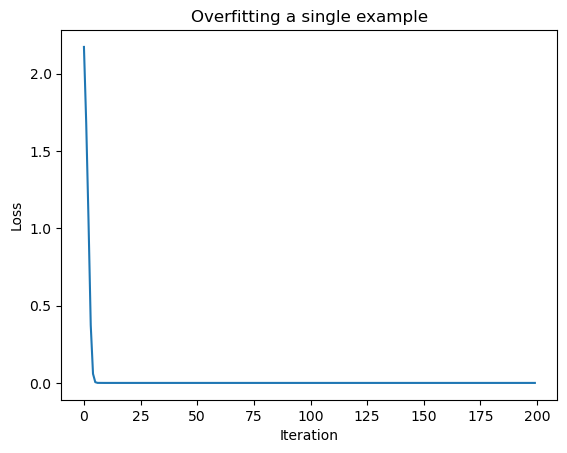

Predicted: 0 True: 0


In [4]:
# TODO: grab one training example (keep the batch dimension)
x_one = X_train_t[0:1]
y_one = y_train_t[0:1]

# TODO: create a fresh model, loss function, and optimizer
torch.manual_seed(42)
model = MNISTNet()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

losses_one = []
for i in range(200):
  # TODO: forward pass, compute loss, zero gradients, backprop, and step the optimizer
  optimizer.zero_grad()
  logits, _ = model(x_one)
  loss = loss_fn(logits, y_one)
  loss.backward()
  optimizer.step()
  losses_one.append(loss.item())

plt.plot(losses_one)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Overfitting a single example")
plt.show()

# TODO: predicted digit for x_one after training, compared to the true label y_one
logits, _ = model(x_one)
predicted_digit = torch.argmax(logits, dim=1)
print("Predicted:", predicted_digit.item(), "True:", y_one.item())

**Check your work:** Your loss curve should drop sharply and flatten out near 0 well before 200 iterations. The predicted digit should exactly match the true label. If it doesn't (or the loss won't budge at all), you likely have a bug — double-check that you're calling `optimizer.zero_grad()` *before* `.backward()` on every iteration (otherwise gradients pile up across iterations instead of resetting), and that you're calling `loss_fn(logits, y_one)` in that order.

---
## Question 3: Train on the Full Dataset

Your training loop works — now scale it up. Instead of one image repeated 200 times, you'll feed the network *mini-batches* of different images, sweep through the whole training set multiple times (each full sweep is called an **epoch**), and check performance on images the network has never seen (the test set).

**Your tasks:**
1. Wrap `X_train_t` and `y_train_t` into a `TensorDataset`, then wrap that in a `DataLoader` with `batch_size=64` and `shuffle=True`.
2. Create a fresh `MNISTNet`, `nn.CrossEntropyLoss()`, and `torch.optim.Adam(model.parameters(), lr=0.001)`.
3. Train for `n_epochs = 5`. For each epoch, loop over the batches your `DataLoader` gives you, and for each batch: forward pass, compute loss, zero gradients, backward, step. Keep a running total of the loss and print the *average* loss for the epoch once it's done.
4. After training, evaluate on the test set: wrap the forward pass in a `with torch.no_grad():` block (no gradients needed for evaluation), get `logits` for all of `X_test_t`, take the `argmax` to get predicted digits, and compute the fraction that match `y_test_t`.

Hint: look up `TensorDataset`, `DataLoader` (iterate over it with a `for` loop — each item is a `(batch_x, batch_y)` pair), `torch.no_grad()`, `torch.argmax(..., dim=1)`, and `(predictions == y_test_t).float().mean()`.

In [5]:
from torch.utils.data import DataLoader, TensorDataset

# TODO: build a TensorDataset and DataLoader (batch_size=64, shuffle=True) from the training data
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

torch.manual_seed(42)
model = MNISTNet()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 5
for epoch in range(n_epochs):
  total_loss = 0.0
  for batch_x, batch_y in train_loader:
    # TODO: forward pass, compute loss, zero gradients, backprop, and step the optimizer
    optimizer.zero_grad()
    logits, _ = model(batch_x)
    loss = loss_fn(logits, batch_y)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  print(
      f"Epoch {epoch+1}/{n_epochs}, avg loss: {total_loss / len(train_loader):.4f}"
  )

# TODO: evaluate accuracy on the test set (no gradients needed)
with torch.no_grad():
  test_logits, _ = model(X_test_t)
  predictions = torch.argmax(test_logits, dim=1)
  test_accuracy = (predictions == y_test_t).float().mean().item()

print("Test accuracy:", test_accuracy)

Epoch 1/5, avg loss: 1.0155
Epoch 2/5, avg loss: 0.3434
Epoch 3/5, avg loss: 0.2696
Epoch 4/5, avg loss: 0.2256
Epoch 5/5, avg loss: 0.1926
Test accuracy: 0.9275000095367432


**Check your work:** Average training loss should drop steadily each epoch. Test accuracy will vary a little by machine, but with this network size and 5 epochs you should comfortably clear 90%, often landing in the low-to-mid 90s. If your accuracy is much lower (or the loss never moves), re-check that `optimizer.zero_grad()` is inside the batch loop, and that you didn't accidentally reuse an already-trained `model` variable from an earlier question.

Keep `model` around — it's the trained network you'll use in Question 5.

---
## Question 4: Meet PCA (With Toy Data)

Your network's embedding layer (Question 1) describes every digit image using 32 numbers. That's too many to put on a scatter plot — we only have an x-axis and a y-axis. **Principal Component Analysis (PCA)** is a technique for squashing many numbers down to just a few, while keeping as much of the *meaningful spread* between data points as possible.

Here's the core idea. Imagine a cloud of points that's stretched out diagonally, like a cigar. PCA finds the direction the cloud stretches out the *most* — that's the **first principal component (PC1)**. Then it finds the next-best direction, at a right angle to the first — the **second principal component (PC2)**. If you only care about the one direction that captures most of the spread, you can describe every point with just its position along PC1, throwing away the rest, and lose relatively little information.

Run the cell below (it's given to you, no TODOs). It builds a fake 2D dataset that's stretched diagonally — small enough to see completely on one plot — fits PCA on it, and draws the two principal component directions as arrows on top of the data.

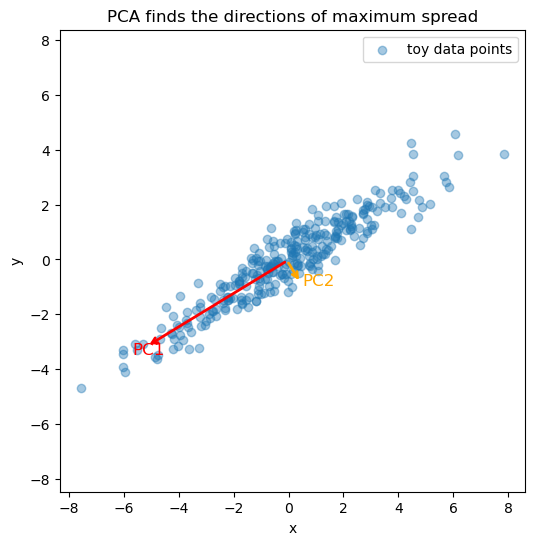

Variance explained by each component: [0.97591504 0.02408496]


In [6]:
# A toy dataset stretched diagonally, so we can see PCA's directions clearly
rng = np.random.default_rng(42)
toy_raw = rng.normal(size=(300, 2)) * np.array([3.0, 0.5])
angle = np.radians(30)
rotation = np.array(
    [[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]]
)
toy_data = toy_raw @ rotation.T

toy_pca = PCA(n_components=2)
toy_pca.fit(toy_data)
center = toy_data.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(toy_data[:, 0], toy_data[:, 1], alpha=0.4, label="toy data points")

for length, vector, color, name in zip(
    toy_pca.explained_variance_,
    toy_pca.components_,
    ["red", "orange"],
    ["PC1", "PC2"],
):
  direction = vector * np.sqrt(length) * 2
  ax.annotate(
      "",
      xy=center + direction,
      xytext=center,
      arrowprops=dict(arrowstyle="->", color=color, linewidth=2),
  )
  ax.text(*(center + direction * 1.1), name, color=color, fontsize=12)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("PCA finds the directions of maximum spread")
ax.axis("equal")
ax.legend()
plt.show()

print("Variance explained by each component:", toy_pca.explained_variance_ratio_)

Notice PC1 (red) points along the long axis of the cigar-shaped cloud — that's the direction with the most spread. PC2 (orange) is perpendicular, capturing whatever spread is left over. The printed `explained_variance_ratio_` tells you what *fraction* of the total spread each component accounts for.

**Your tasks:**
1. Using `toy_data`, fit a `PCA(n_components=1)` — keeping only PC1 — and use `.fit_transform()` to project every point down to a single number.
2. Make a 1D plot of those projected values (a histogram, or a scatter plot against a constant y — whichever you like) to see what the data looks like once squashed onto just PC1.
3. Print `.explained_variance_ratio_` for this 1-component PCA. What fraction of the toy data's spread survives being squashed down to one number?

Hint: look up `PCA(n_components=...)`, `.fit_transform()`, and `.explained_variance_ratio_`.

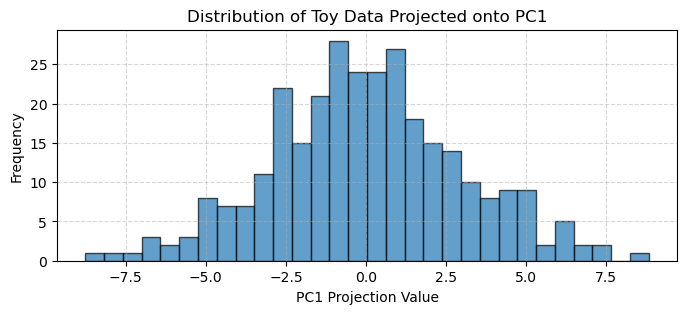

Variance kept with 1 component: 0.9759150409553818


In [7]:
# TODO: fit PCA(n_components=1) on toy_data and project every point onto PC1
toy_pca_1d = PCA(n_components=1)
toy_projected = toy_pca_1d.fit_transform(toy_data)

# TODO: plot the 1D projected values (histogram, or a 1D scatter against a constant y)
plt.figure(figsize=(8, 3))
plt.hist(toy_projected, bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("PC1 Projection Value")
plt.ylabel("Frequency")
plt.title("Distribution of Toy Data Projected onto PC1")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# TODO: what fraction of variance is kept with just 1 component?
variance_kept = toy_pca_1d.explained_variance_ratio_[0]
print("Variance kept with 1 component:", variance_kept)

**Check your work:** You should keep roughly 90%+ of the toy data's variance with just PC1 — it was built to stretch mostly along one diagonal direction, so squashing it down to that direction throws away relatively little. Compare this to `toy_pca.explained_variance_ratio_[0]` printed in the cell above — they should match.

---
## Question 5 (Capstone): Discover the Clusters

Time for the payoff. Your trained network (from Question 3) takes any digit image and produces a 32-number `embedding` for it. If the network has learned to tell digits apart well, images of the *same* digit should end up with *similar* embeddings — even though nothing in your training loop ever told the network to group anything. Let's check, using PCA to squash those 32 numbers down to 2, so we can see them on a scatter plot.

**Your tasks:**
1. Using your trained `model` from Question 3, run all of `X_test_t` through it inside a `with torch.no_grad():` block, and pull out the `embedding` output. Convert it to a NumPy array (look up `.numpy()` on a tensor).
2. Fit a `PCA(n_components=2)` on those embeddings and transform them down to 2D.
3. Make a scatter plot of the 2D projected embeddings, coloring each point by its true digit label (`y_test`, 0-9) — try looping over each digit value and plotting its points with a different color/label, the same way you looped over `species` in the iris workshop.
4. Print the `.explained_variance_ratio_` for this PCA — how much of the embedding's spread do 2 components capture?
5. **Bonus comparison:** Do the exact same thing (PCA down to 2D, scatter colored by digit), but starting from the *raw pixel values* (`X_test`) instead of the network's embeddings. Compare the two plots — which one separates the digits more cleanly? What does that tell you about what the network learned?

Hint: look up `Tensor.numpy()`, `PCA(n_components=2)`, `.fit_transform()`, and loop over `np.unique(y_test)` to color by digit, the same way you looped over species with `groupby` in the iris workshop.

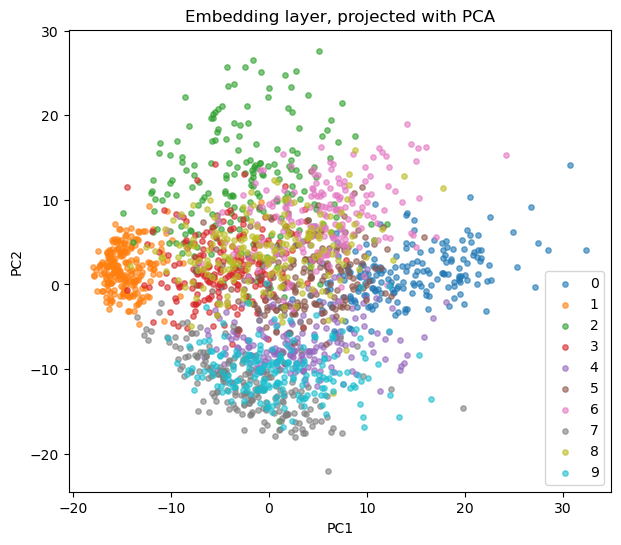

Variance explained: [0.26500317 0.23416813]


In [8]:
# TODO: get embeddings for the whole test set from your trained model (no gradients needed)
with torch.no_grad():
  test_logits, test_embeddings = model(X_test_t)

test_embeddings_np = test_embeddings.numpy()

# TODO: fit PCA(n_components=2) on the embeddings and project them down to 2D
embedding_pca = PCA(n_components=2)
embeddings_2d = embedding_pca.fit_transform(test_embeddings_np)

# TODO: scatter plot embeddings_2d, colored by true digit (y_test)
plt.figure(figsize=(7, 6))
for digit in np.unique(y_test):
  mask = y_test == digit
  plt.scatter(
      embeddings_2d[mask, 0],
      embeddings_2d[mask, 1],
      label=str(digit),
      alpha=0.6,
      s=15,
  )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Embedding layer, projected with PCA")
plt.legend()
plt.show()

# TODO: what fraction of the embedding's variance do 2 components capture?
embedding_variance_kept = embedding_pca.explained_variance_ratio_
print("Variance explained:", embedding_variance_kept)

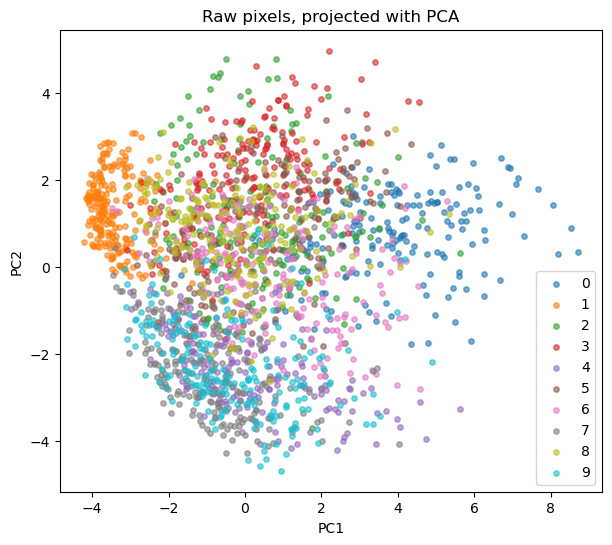

In [9]:
# TODO (bonus): repeat PCA + scatter, but starting from raw pixels (X_test) instead of embeddings
pixel_pca = PCA(n_components=2)
pixels_2d = pixel_pca.fit_transform(X_test)

plt.figure(figsize=(7, 6))
for digit in np.unique(y_test):
  mask = y_test == digit
  plt.scatter(
      pixels_2d[mask, 0],
      pixels_2d[mask, 1],
      label=str(digit),
      alpha=0.6,
      s=15,
  )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Raw pixels, projected with PCA")
plt.legend()
plt.show()

**Check your work:** In the embedding PCA plot, you should see fairly distinct colored clusters — most digits form their own loose blob, with some overlap between visually similar digits (like 4/9, or 3/5/8). In the raw-pixel PCA plot, the colors will be much more smeared together — raw pixel brightness alone doesn't separate digits nearly as well as the representation your network learned. That's the punchline: a network trained *only* to get the classification right discovered, on its own, a way of describing images where same-digit images land near each other. Nobody told it to cluster anything — clustering fell out of learning to classify.

**Your reflection (2-3 sentences):** Compare the embedding-PCA plot to the raw-pixel-PCA plot. What does the difference tell you about what the network's hidden layers actually learned to do?

The raw-pixel-PCA plot shows heavy overlap between digits because raw brightness values retain irrelevances like line thickness, alignment, and slight shifts, while the embedding plot displays distinct and packed clusters for each digit category. This demonstrates that the network's hidden layers learned to transform raw visual data into something meaningful instead of just pixel patterns.